# Machine Learning In Class Excersise

In [29]:
# 1. Imports
import os
import pandas as pd
import sys

from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.ensemble import * 
from sklearn.metrics import *

from matplotlib import pyplot as plt 
import seaborn as sns

print(sys.version)
print(os.environ['CONDA_DEFAULT_ENV'])

3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
testenv


In [30]:
# 2. get wine with quality date
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

In [31]:
# 3. read csv file into df
df = pd.read_csv(wine_url, sep=";")

## Display dataframe characteristics

In [32]:
df.shape

(1599, 12)

In [33]:
#5. use pandas df info method
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [34]:
#6. print data frame statistic summary format data frame to two decimal places, w thousand seperator
pd.options.display.float_format = '{:,.2f}'.format
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,"1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00"
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [35]:
#7. print data frame attributes. index, columns, size, and shapes
print("index:", df.index)
print("columns:", df.columns)
print("size:", df.size)
print("shape:", df.shape)

index: RangeIndex(start=0, stop=1599, step=1)
columns: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
size: 19188
shape: (1599, 12)


In [36]:
#8. display first and last 5 rows with one command
pd.concat([df.head(), df.tail()])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
1594,6.20,0.60,0.08,2.00,0.09,32.00,44.00,0.99,3.45,0.58,10.50,5
1595,5.90,0.55,0.10,2.20,0.06,39.00,51.00,1.00,3.52,0.76,11.20,6
1596,6.30,0.51,0.13,2.30,0.08,29.00,40.00,1.00,3.42,0.75,11.00,6
1597,5.90,0.65,0.12,2.00,0.07,32.00,44.00,1.00,3.57,0.71,10.20,5
1598,6.00,0.31,0.47,3.60,0.07,18.00,42.00,1.00,3.39,0.66,11.00,6


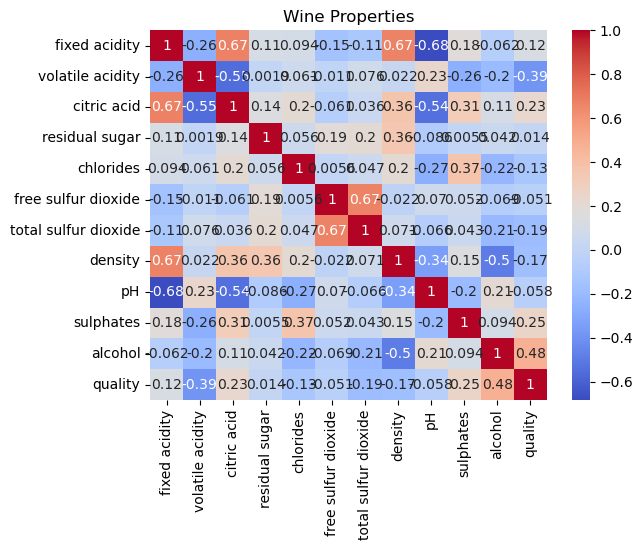

In [37]:
#9. display correlation matrix, cool warm palette
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Wine Properties')
plt.show()

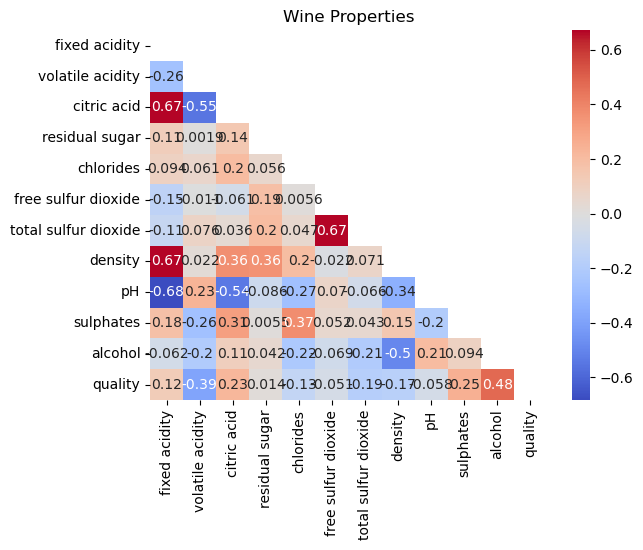

In [38]:
#10. masked "triangular" heatmap: make heatmap cleaner, apply mask to hide top right triangle

import numpy as np

mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', mask=mask)
plt.title('Wine Properties')
plt.show()

## Create independent/ dependent variables

In [46]:
#11. create new col indicating "is_good" based upon existing "quality" col
df['is_good'] = (df['quality'] >= 7).astype(int)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_good
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,0
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5,0
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5,0
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6,0
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.20,0.60,0.08,2.00,0.09,32.00,44.00,0.99,3.45,0.58,10.50,5,0
1595,5.90,0.55,0.10,2.20,0.06,39.00,51.00,1.00,3.52,0.76,11.20,6,0
1596,6.30,0.51,0.13,2.30,0.08,29.00,40.00,1.00,3.42,0.75,11.00,6,0
1597,5.90,0.65,0.12,2.00,0.07,32.00,44.00,1.00,3.57,0.71,10.20,5,0


In [47]:
#12. create and display independent variable X by removing quality and is_good cols
X = df.drop(columns=['quality', 'is_good'])
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.20,0.60,0.08,2.00,0.09,32.00,44.00,0.99,3.45,0.58,10.50
1595,5.90,0.55,0.10,2.20,0.06,39.00,51.00,1.00,3.52,0.76,11.20
1596,6.30,0.51,0.13,2.30,0.08,29.00,40.00,1.00,3.42,0.75,11.00
1597,5.90,0.65,0.12,2.00,0.07,32.00,44.00,1.00,3.57,0.71,10.20


In [48]:
#13. create and display dependent variable y from is_good col
y = df['is_good']
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: is_good, Length: 1599, dtype: int64

## Prepare Model

In [49]:
#14. split data, 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [50]:
#15. scale features (z-score normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
#16. display new X train scaled feature values
X_train

array([[ 0.21833164,  0.88971201,  0.19209222, ...,  1.09349989,
         0.45822284,  1.12317723],
       [-1.29016623, -1.78878251,  0.65275338, ..., -0.40043872,
        -0.40119696,  1.40827174],
       [ 1.49475291, -0.78434707,  1.01104539, ..., -0.07566946,
         0.51551749, -0.58738978],
       ...,
       [-0.65195559,  0.49909822, -1.08752211, ...,  1.28836145,
        -0.68767023, -0.87248428],
       [-0.24582155, -1.84458448,  0.39683051, ...,  0.05423824,
         0.80199076,  1.40827174],
       [-1.46422367, -1.34236676, -0.06383064, ...,  0.50891521,
        -0.68767023,  2.92877575]])

## Train and Assess

In [52]:
# 18. Train and Evaluate/Assess:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# b. print accuracy of model
print("Accuracy:", accuracy_score(y_test, predictions))

# c. print classification report
print(classification_report(y_test, predictions))

# d. what classification_report() does:
# Precision:    of all predicted positives, how many were actually positive
# Recall:       of all actual positives, how many did the model correctly identify
# F1-Score:     harmonic mean of precision and recall, balances both metrics
# Support:      number of actual occurrences of each class in the test set

# Accuracy:         overall % of correct predictions across all classes
# Macro Average:    averages each metric equally across classes, regardless of class size
# Weighted Average: averages each metric weighted by each class's support (handles imbalanced data)

Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       273
           1       0.73      0.51      0.60        47

    accuracy                           0.90       320
   macro avg       0.82      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



## Plot Data

In [53]:
# 19. Extract feature_importances (chemical properties that most significantly impact wine's quality rating)

# create DataFrame for easier plotting
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# display DF feature_importance
feature_importance

,Feature,Importance
10,alcohol,0.17
9,sulphates,0.12
1,volatile acidity,0.11
7,density,0.09
2,citric acid,0.09
6,total sulfur dioxide,0.09
4,chlorides,0.08
0,fixed acidity,0.07
3,residual sugar,0.07
8,pH,0.06


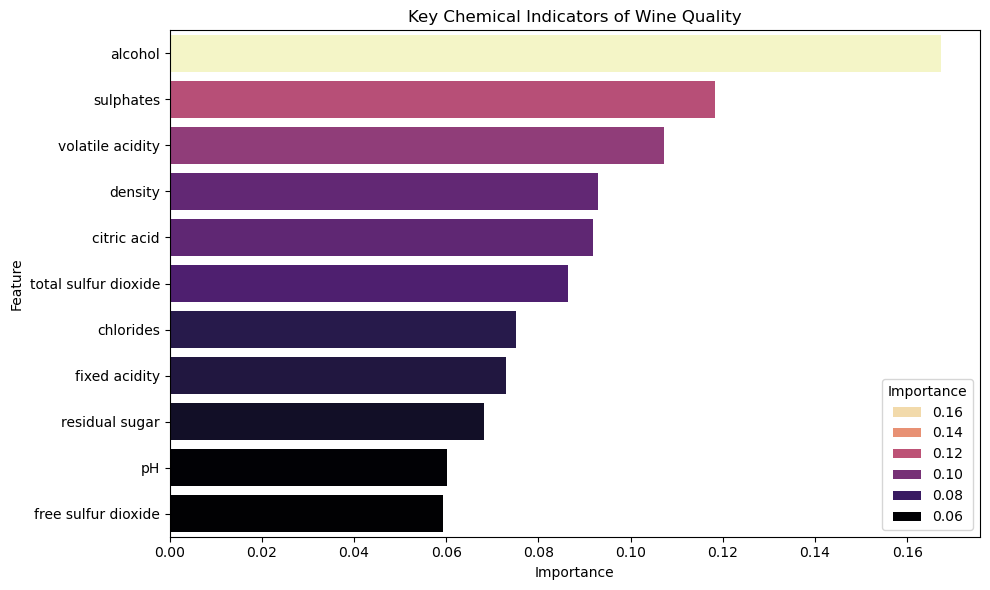

In [58]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=feature_importance, x='Importance', y='Feature',
            palette='magma', hue='Importance', legend=True)

plt.title('Key Chemical Indicators of Wine Quality')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Importance')

plt.tight_layout()
plt.show()